# EchoVision Wave Demo — Q6 Fixed Bitstream

Run this **after** rebuilding the bitstream in Vivado and copying the new `.bit` / `.hwh` to the board.

**Current pixel_generator.v has ONE display mode only — the wave solver.**
Registers in use: `gp0` (fire pulse), `gp1` (source XY), `gp4` (gain), `gp5` (phase_step + duration).
All other gp registers are wired to AXI but not consumed by the HDL.

Key fixes vs old notebooks:
- `VideoMode(640, 480, **32**)` — matches 32-bit one-beat-per-pixel AXI stream
- `corrected_rgb` uses `[:, :, :3]` — drops 0x00 alpha, no channel swap needed
- No mode 5/6/7/8 calls — those do not exist in the current HDL

In [1]:
import os
import json
import time
import shutil
from datetime import datetime
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from PIL import Image as PILImage
from IPython.display import display, Image as IPyImage

from pynq import Overlay
from pynq.lib.video import VideoMode

# ── CONFIGURE THESE ─────────────────────────────────────────────────────────
SOURCE_FOLDER = '/home/xilinx/jupyter_notebooks'
BIT_FILE_NAME = 'base.bit'
HWH_FILE_NAME = 'base.hwh'
# BIT_FILE_NAME = 'finalv14.bit'
# HWH_FILE_NAME = 'finalv14.hwh'
BPP = 32  # 32-bit one-beat-per-pixel — must match Q6 HDL (was 24 in old notebooks)
# ────────────────────────────────────────────────────────────────────────────

RUN_NAME  = datetime.now().strftime('wave_demo_%Y%m%d_%H%M%S')
OUT_DIR   = Path('/home/xilinx/jupyter_notebooks/echovision/test_runs') / RUN_NAME
FRAME_DIR = OUT_DIR / 'frames'
LOG_DIR   = OUT_DIR / 'logs'
for d in [OUT_DIR, FRAME_DIR, LOG_DIR]:
    d.mkdir(parents=True, exist_ok=True)

print('Output dir:', OUT_DIR)
print('Imports OK')

Output dir: /home/xilinx/jupyter_notebooks/echovision/test_runs/wave_demo_20260602_093900
Imports OK


In [2]:
# Copy bitstream so .bit and .hwh share the same stem — PYNQ requires this.
src_bit = Path(SOURCE_FOLDER) / BIT_FILE_NAME
src_hwh = Path(SOURCE_FOLDER) / HWH_FILE_NAME

for p in [src_bit, src_hwh]:
    if not p.exists():
        print('Files in folder:')
        for f in sorted(Path(SOURCE_FOLDER).iterdir()):
            print(' -', f.name)
        raise FileNotFoundError(str(p))

# BIT_PATH = OUT_DIR / 'base.bit'
# HWH_PATH = OUT_DIR / 'base.hwh'
BIT_PATH = OUT_DIR / 'echovision_q6.bit'
HWH_PATH = OUT_DIR / 'echovision_q6.hwh'
shutil.copy2(src_bit, BIT_PATH)
shutil.copy2(src_hwh, HWH_PATH)

print('BIT:', BIT_PATH, os.path.getsize(BIT_PATH), 'bytes')
print('BIT built:', time.ctime(os.path.getmtime(src_bit)))

print('\nLoading overlay...')
overlay = Overlay(str(BIT_PATH))
overlay.download()
print('Overlay loaded')

print('\nIP blocks:')
for name in overlay.ip_dict.keys():
    print(' -', name)

pixgen     = overlay.pixel_generator_0
imgen_vdma = overlay.video.axi_vdma_0.readchannel
hdmi_out   = overlay.video.hdmi_out
hdmi_out._vdma = overlay.video.axi_vdma

print('\npixgen:', pixgen)
print('Register map:')
print(pixgen.register_map)

BIT: /home/xilinx/jupyter_notebooks/echovision/test_runs/wave_demo_20260602_093900/echovision_q6.bit 4045672 bytes
BIT built: Tue Jun  2 09:19:17 2026

Loading overlay...
Overlay loaded

IP blocks:
 - video/hdmi_in/frontend/vtc_in
 - video/hdmi_out/frontend/vtc_out
 - pixel_generator_0
 - switches_gpio
 - btns_gpio
 - video/hdmi_in/frontend/axi_gpio_hdmiin
 - video/hdmi_out/frontend/hdmi_out_hpd_video
 - rgbleds_gpio
 - leds_gpio
 - system_interrupts
 - video/axi_vdma
 - video/axi_vdma_0
 - audio_direct_0
 - video/hdmi_out/frontend/axi_dynclk
 - video/hdmi_in/pixel_pack
 - video/hdmi_in/color_convert
 - video/hdmi_out/color_convert
 - video/hdmi_out/pixel_unpack
 - trace_analyzer_pmoda/axi_dma_0
 - trace_analyzer_arduino/axi_dma_0
 - trace_analyzer_arduino/trace_cntrl_64_0
 - trace_analyzer_pmoda/trace_cntrl_32_0
 - ps7_0

pixgen: <pynq.overlay.DefaultIP object at 0xb3882388>
Register map:
RegisterMap {
  gp0 = Register(value=0),
  gp1 = Register(value=0),
  gp2 = Register(value=0),
  

In [3]:
print('Resetting old video state...')
for fn in [imgen_vdma.stop, hdmi_out.close]:
    try:
        fn()
        time.sleep(0.3)
    except Exception as e:
        print('Skipped:', repr(e))

# BPP=32 is required — the Q6 HDL outputs one 32-bit word per pixel.
# With BPP=24 the VDMA geometry is wrong and frames will be mangled.
videoMode = VideoMode(640, 480, BPP)
print('Video mode:', videoMode)

imgen_vdma.mode = videoMode
imgen_vdma.start()
time.sleep(0.5)
print('VDMA running:', imgen_vdma.running)

hdmi_out.configure(videoMode)
hdmi_out.start()
time.sleep(0.5)
print('HDMI started')

Resetting old video state...
Video mode: VideoMode: width=640 height=480 bpp=32 fps=60
VDMA running: True
HDMI started


In [4]:
def pack_xy(x, y):
    # Output-space coords (0-639, 0-479). HDL divides by 4 for 160x120 solver grid.
    return (int(y) << 10) | int(x)

def pack_source_control(phase_step=4, duration=16):
    return ((int(duration) & 0xFF) << 8) | (int(phase_step) & 0x3F)

def configure_wave_source(x=320, y=240, gain=140, phase_step=4, duration=16):
    pixgen.register_map.gp1 = pack_xy(x, y)
    pixgen.register_map.gp4 = int(gain)
    pixgen.register_map.gp5 = pack_source_control(phase_step, duration)
    print(f'Source: x={x}, y={y}, gain={gain}, phase_step={phase_step}, duration={duration}')

def configure_object(center_x=320, center_y=240, half_w=10, half_h=10, enable=True):
    ctrl = (1 << 31) if enable else 0
    pixgen.register_map.gp2 = ctrl | pack_xy(center_x, center_y)
    pixgen.register_map.gp3 = ((int(half_h) & 0xFF) << 8) | (int(half_w) & 0xFF)
    print(
        f'Object: display center=({center_x},{center_y}), '
        f'sim center=({center_x//4},{center_y//4}), '
        f'half=({half_w},{half_h}) sim cells'
    )
    
def fire_source():
    # Rising edge on gp0[0] triggers one sine burst.
    pixgen.register_map.gp0 = 0
    time.sleep(0.02)
    pixgen.register_map.gp0 = 1
    time.sleep(0.02)
    pixgen.register_map.gp0 = 0

def get_registers():
    return {f'gp{i}': int(getattr(pixgen.register_map, f'gp{i}')) for i in range(8)}

def ensure_video():
    if not getattr(imgen_vdma, 'running', False):
        imgen_vdma.mode = videoMode
        imgen_vdma.start()
        time.sleep(0.5)

def capture_frame(to_hdmi=True):
    ensure_video()
    frame = imgen_vdma.readframe()
    arr = np.array(frame)
    if to_hdmi:
        hdmi_out.writeframe(frame)
    return arr

def corrected_rgb(arr):
    # 32-bit stream: bytes in memory are [R, G, B, 0x00]. Drop alpha, no swap.
    img = np.array(arr)
    if img.ndim == 3 and img.shape[2] >= 3:
        return img[:, :, :3]
    return img

def show_frame(arr, title=''):
    plt.figure(figsize=(8, 5))
    plt.imshow(corrected_rgb(arr))
    plt.title(title)
    plt.axis('off')
    plt.tight_layout()
    plt.show()

def save_png(arr, name):
    PILImage.fromarray(corrected_rgb(arr).astype(np.uint8)).save(FRAME_DIR / name)

print('Helpers ready')

Helpers ready


## Solver Alive Check

Captures two frames 0.75 s apart **without firing a pulse**.
The solver runs continuously so frames should differ slightly from the damped-decay noise floor.
If `mean_diff == 0` the solver is completely frozen — recheck the bitstream loaded correctly.

Then fires one test pulse and checks that frames change significantly.

=== Solver alive check ===
Idle mean_diff (no pulse, 0.75 s apart): 0.000


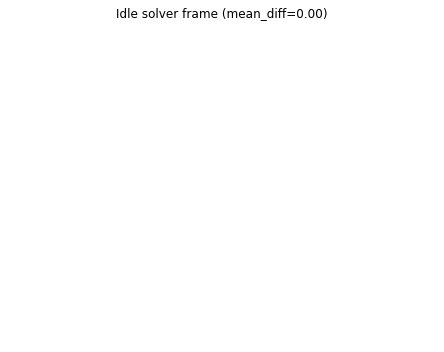


Firing test pulse...
Object: display center=(320,240), sim center=(80,60), half=(10,10) sim cells
Source: x=200, y=240, gain=180, phase_step=4, duration=12
Post-pulse mean_diff: 5.412
PASS — solver is running and wave is propagating


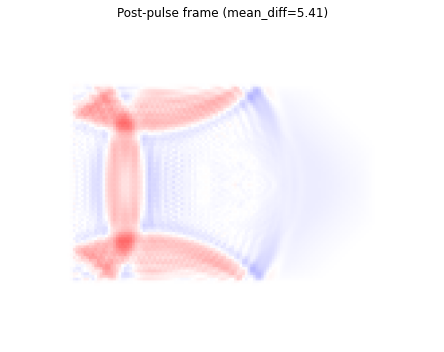

In [5]:
print('=== Solver alive check ===')

# Make sure gp0 is low (no pending fire edge)
pixgen.register_map.gp0 = 0
time.sleep(0.3)

arr_a = capture_frame()
time.sleep(0.75)
arr_b = capture_frame()

idle_diff = np.abs(arr_a.astype(np.int16) - arr_b.astype(np.int16)).mean()
print(f'Idle mean_diff (no pulse, 0.75 s apart): {idle_diff:.3f}')
# With a perfectly flat solver this may be near 0 — that is fine at idle.
# The real test is after firing a pulse below.

show_frame(arr_b, f'Idle solver frame (mean_diff={idle_diff:.2f})')
save_png(arr_b, 'alive_check_idle.png')

# Fire a test pulse and confirm frame content changes
print('\nFiring test pulse...')
configure_object(center_x=320, center_y=240, half_w=10, half_h=10)
configure_wave_source(x=200, y=240, gain=180, phase_step=4, duration=12)
fire_source()
time.sleep(0.3)

arr_c = capture_frame()
time.sleep(0.5)
arr_d = capture_frame()

pulse_diff = np.abs(arr_c.astype(np.int16) - arr_d.astype(np.int16)).mean()
print(f'Post-pulse mean_diff: {pulse_diff:.3f}')

if pulse_diff > 0.5:
    print('PASS — solver is running and wave is propagating')
else:
    print('WARNING — frames barely changing after pulse; check bitstream and VideoMode')

show_frame(arr_d, f'Post-pulse frame (mean_diff={pulse_diff:.2f})')
save_png(arr_d, 'alive_check_post_pulse.png')

## 2-Pulse 10-Second Wave Animation

- **Pulse 1** fires at t = 0 s.
- **Pulse 2** fires at t ≈ 4.5 s.
- Captures for 10 s at live frame rate, saves every 4th frame to a GIF, displays it inline.

**Expected result with fixed bitstream:** A circular ring expands from the centre. Red = positive pressure (leading edge), blue = negative (trailing echo). After ~4.5 s a second ring appears and the two interfere.

Object: display center=(320,240), sim center=(80,60), half=(10,10) sim cells
Source: x=200, y=240, gain=180, phase_step=4, duration=12
Firing pulse 1 at t=0 s ...
Firing pulse 2 at t=4.51 s ...
Captured 314 frames in 10.0 s  (31.4 fps)
GIF frames: 78  (127 ms/frame)
GIF saved: /home/xilinx/jupyter_notebooks/echovision/test_runs/wave_demo_20260602_093900/frames/wave_2pulse_10s.gif


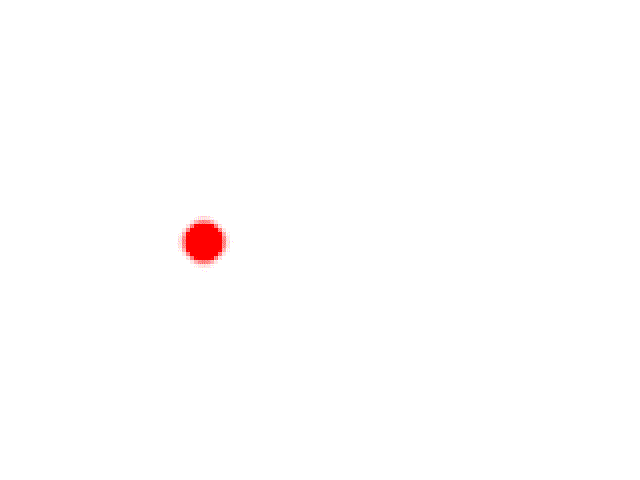

All evidence saved to: /home/xilinx/jupyter_notebooks/echovision/test_runs/wave_demo_20260602_093900


In [5]:
# ── Parameters ───────────────────────────────────────────────────────────────
SOURCE_X     = 320   # pulse origin x (output-space, 0-639)
SOURCE_Y     = 240   # pulse origin y (output-space, 0-479)
GAIN         = 150   # amplitude (140-180 recommended for Q6 HDL)
PHASE_STEP   = 4     # sine LUT speed
BURST_FRAMES = 16    # solver frames per pulse

ANIM_SECONDS = 10.0  # total capture time
PULSE2_AT_S  = 4.5   # fire second pulse this many seconds after start
SAMPLE_EVERY = 4     # save every Nth frame to keep GIF size reasonable
# ────────────────────────────────────────────────────────────────────────────

configure_object(center_x=400, center_y=300, half_w=10, half_h=10)
configure_wave_source(x=200, y=240, gain=180, phase_step=4, duration=12)
time.sleep(0.5)

print(f'Firing pulse 1 at t=0 s ...')
fire_source()

gif_frames   = []
frame_count  = 0
pulse2_fired = False
start        = time.time()

while True:
    elapsed = time.time() - start
    if elapsed >= ANIM_SECONDS:
        break

    if not pulse2_fired and elapsed >= PULSE2_AT_S:
        print(f'Firing pulse 2 at t={elapsed:.2f} s ...')
        fire_source()
        pulse2_fired = True

    arr = capture_frame(to_hdmi=True)
    frame_count += 1

    if frame_count % SAMPLE_EVERY == 0:
        gif_frames.append(
            PILImage.fromarray(corrected_rgb(arr).astype(np.uint8))
        )

elapsed_total = time.time() - start
fps = frame_count / elapsed_total if elapsed_total > 0 else 1
ms_per_frame = int(1000.0 / fps * SAMPLE_EVERY)

print(f'Captured {frame_count} frames in {elapsed_total:.1f} s  ({fps:.1f} fps)')
print(f'GIF frames: {len(gif_frames)}  ({ms_per_frame} ms/frame)')

if not gif_frames:
    raise RuntimeError('No frames captured — check VDMA / video pipeline')

gif_path = FRAME_DIR / 'wave_2pulse_10s.gif'
gif_frames[0].save(
    gif_path,
    save_all=True,
    append_images=gif_frames[1:],
    duration=ms_per_frame,
    loop=0,
)
print('GIF saved:', gif_path)
display(IPyImage(filename=str(gif_path)))

# Save key frames as PNG evidence
n = len(gif_frames)
save_png(np.array(gif_frames[0]),        'wave_frame_start.png')
save_png(np.array(gif_frames[n // 3]),   'wave_frame_pulse1_peak.png')
save_png(np.array(gif_frames[n * 2 // 3]), 'wave_frame_pulse2_peak.png')
save_png(np.array(gif_frames[-1]),       'wave_frame_end.png')

with open(LOG_DIR / 'run_meta.json', 'w') as f:
    json.dump({
        'source_x': SOURCE_X, 'source_y': SOURCE_Y,
        'gain': GAIN, 'phase_step': PHASE_STEP, 'burst_frames': BURST_FRAMES,
        'pulse2_at_s': PULSE2_AT_S, 'total_frames': frame_count,
        'gif_frames': n, 'fps': fps, 'registers': get_registers(),
    }, f, indent=2)

print('All evidence saved to:', OUT_DIR)

## Cleanup

In [ ]:
pixgen.register_map.gp0 = 0
for fn in [imgen_vdma.stop, hdmi_out.close]:
    try:
        fn(); time.sleep(0.2); print('OK:', fn.__qualname__)
    except Exception as e:
        print('Skipped:', repr(e))
print('Done — output in:', OUT_DIR)

OK: AxiVDMA.S2MMChannel.stop
